In [2]:
#Dataset Diabetes prediction from kaggle datasets
import pandas as pd
data = pd.read_csv("diabetes_prediction_dataset.csv.zip")
data

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [10]:
data.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [11]:
data.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [5]:
data.shape

(100000, 9)

In [12]:
data.columns = data.columns.str.lower()

In [8]:
data.isnull().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

In [14]:
data.duplicated().sum()

np.int64(3854)

In [15]:
data.drop_duplicates()

,gender,age,hypertension,heart_disease,smoking_history,bmi,hba1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0
...,...,...,...,...,...,...,...,...,...
99994,Female,36.0,0,0,No Info,24.60,4.8,145,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0


In [18]:
num_cols = ['age', 'bmi', 'HbA1c_level', 'blood_glucose_level']

for col in num_cols:

    Q1 = data[col].quantile(0.25)
    Q3 = data[col].quantile(0.75)

    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = data[(data[col] < lower_bound) | (data[col] > upper_bound)]

    print(f"\nColumn: {col}")
    print("Q1:", Q1)
    print("Q3:", Q3)
    print("Lower Bound:", lower_bound)
    print("Upper Bound:", upper_bound)
    print("Number of Outliers:", len(outliers))


Column: age
Q1: 24.0
Q3: 60.0
Lower Bound: -30.0
Upper Bound: 114.0
Number of Outliers: 0

Column: bmi
Q1: 23.63
Q3: 29.58
Lower Bound: 14.705
Upper Bound: 38.504999999999995
Number of Outliers: 7086

Column: HbA1c_level
Q1: 4.8
Q3: 6.2
Lower Bound: 2.6999999999999993
Upper Bound: 8.3
Number of Outliers: 1315

Column: blood_glucose_level
Q1: 100.0
Q3: 159.0
Lower Bound: 11.5
Upper Bound: 247.5
Number of Outliers: 2038


In [23]:
data['diabetes'].value_counts()

diabetes
0    91500
1     8500
Name: count, dtype: int64

<Axes: xlabel='gender', ylabel='count'>

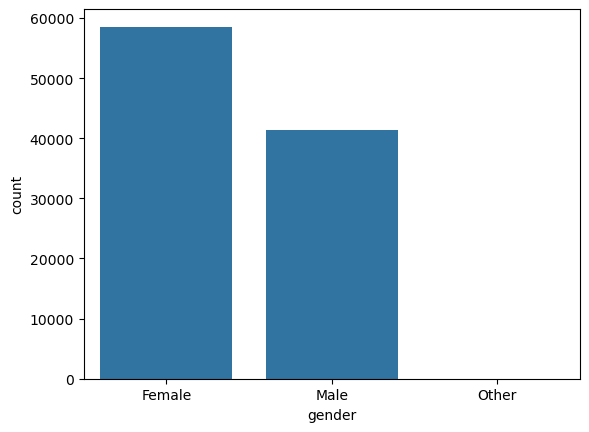

In [3]:
#univariate analysis
import seaborn as sns
sns.countplot(x='gender', data=data)

<Axes: xlabel='count', ylabel='smoking_history'>

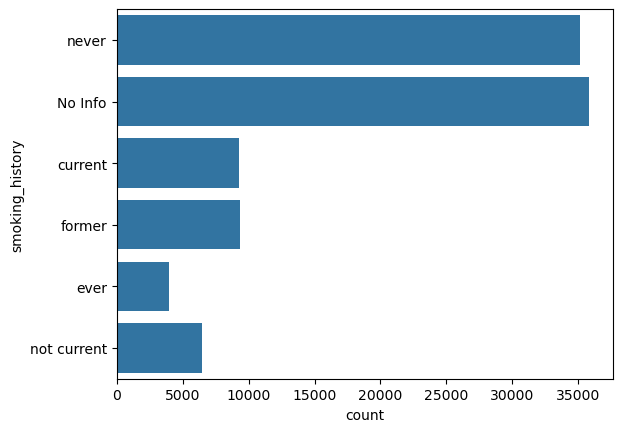

In [27]:
sns.countplot(y='smoking_history', data=data)

<Axes: xlabel='age', ylabel='Count'>

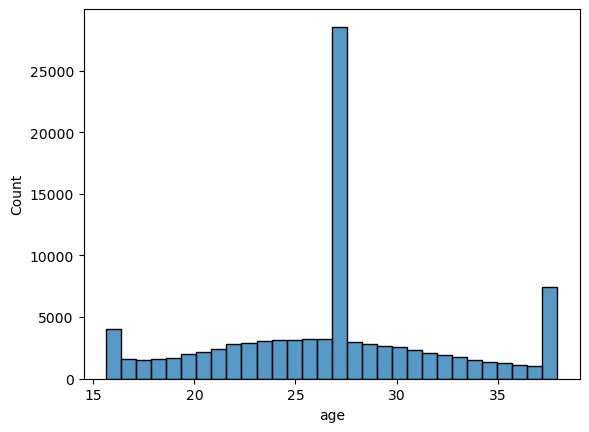

In [29]:
sns.histplot(data['age'], bins=30)

<Axes: xlabel='bmi', ylabel='Count'>

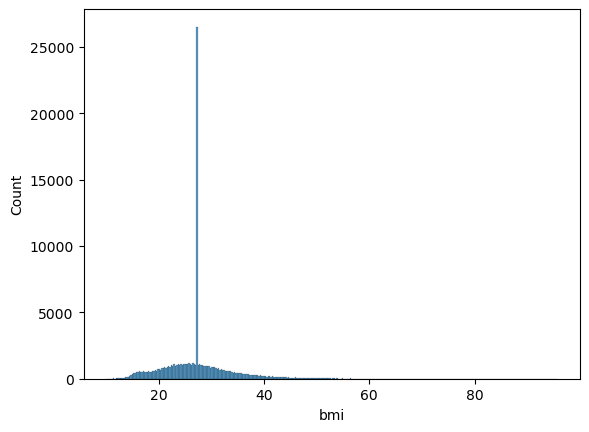

In [30]:
sns.histplot(data['bmi'])

<Axes: xlabel='gender', ylabel='count'>

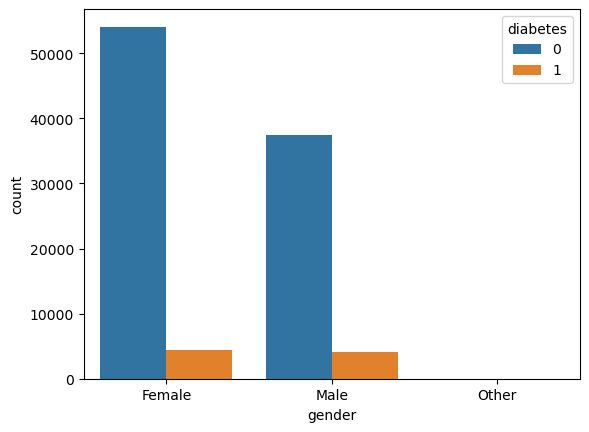

In [32]:
#Bivariate
sns.countplot(x='gender',hue='diabetes',data=data)

<Axes: xlabel='hypertension', ylabel='count'>

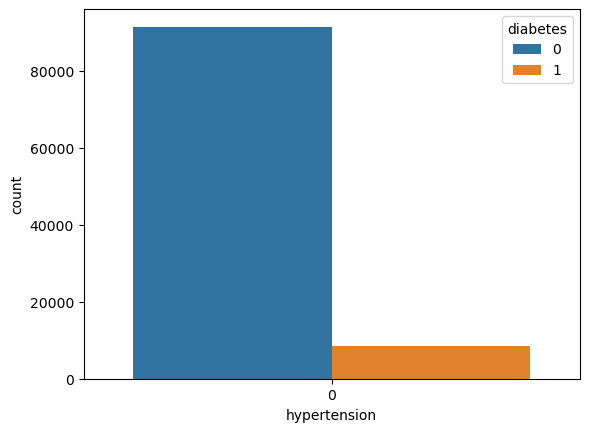

In [33]:
sns.countplot(x='hypertension',hue='diabetes',data=data)

<Axes: xlabel='heart_disease', ylabel='count'>

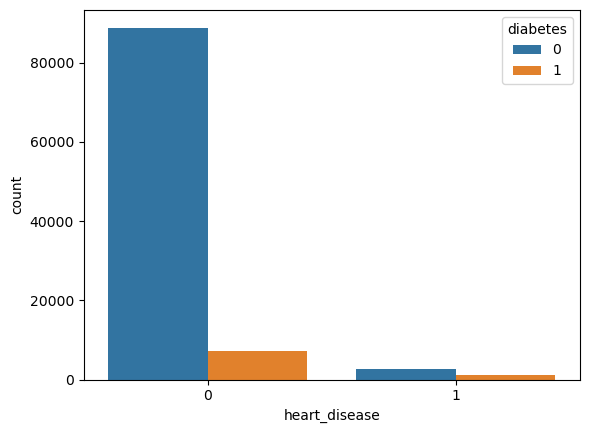

In [34]:
sns.countplot(x='heart_disease',hue='diabetes',data=data)

In [4]:
#pivot tables
pd.pivot_table(data,values='diabetes',index='gender',aggfunc='mean')

,diabetes
gender,
Female,0.076189
Male,0.097490
Other,0.000000


In [5]:
pd.pivot_table(data,values='diabetes',index='smoking_history',aggfunc='mean')

,diabetes
smoking_history,
No Info,0.040596
current,0.102089
ever,0.117882
former,0.170017
never,0.095341
not current,0.107027


In [6]:
pd.pivot_table(data,values='blood_glucose_level',index='diabetes',aggfunc='mean')

,blood_glucose_level
diabetes,
0,132.852470
1,194.094706
